In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_blobs
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import time
import pandas as pd
from scipy.interpolate import LSQUnivariateSpline

In [2]:
RANDOM_STATE = 42

# Task 1
Build a 2D multimodal Gaussian distribution with synthetic data.

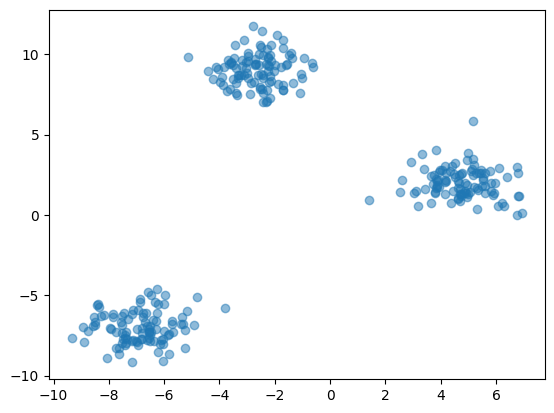

In [3]:
# create 3 sets of 2D gaussian distribution blobs
blob_x_y, _ = make_blobs(n_samples=300, n_features=2, centers=3, random_state=RANDOM_STATE)
X = blob_x_y[:, 0].reshape(-1, 1)
y = blob_x_y[:, 1]
plt.scatter(X, y, alpha=0.5)
plt.show()

# Task 2
Construct a piecewise **linear** regression and plot the result with its splines and knots.

Best F-statistic: 43.84772645670232
Number of knots: 6
RMSE: 1.8259
R²: 0.9242


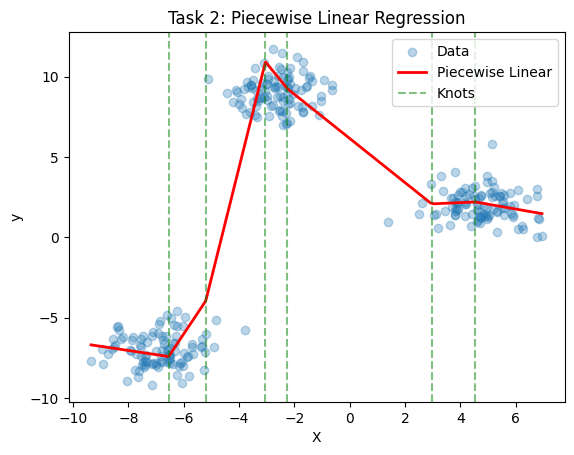

In [4]:
def piecewise_linear_features(X, knots):
    """
    Create piecewise linear features
    y = β₀ + β₁x + β₂(x-k₁)₊ + β₃(x-k₂)₊ + ...
    """
    X_flat = X.flatten()
    features = np.column_stack([X_flat] + [np.maximum(0, X_flat - k) for k in knots])
    return features

# define hyperparameters for knot selection
max_knots = int(len(X) / 50)  # one knot per 50 data points
lower_perc = 20
upper_perc = 80

# test different numbers of knots using F-test
start_time = time.time()

for n_knots in range(1, max_knots+1):
    knots = np.percentile(X, np.linspace(lower_perc, upper_perc, n_knots))
    X_pw = piecewise_linear_features(X, knots)

    # fit the model, generate predictions
    model = LinearRegression()
    model.fit(X_pw, y)
    y_pred = model.predict(X_pw)

    # calculate RSS and F-statistic terms
    rss = np.sum((y - y_pred)**2)
    n = len(y)  # number of observations
    p = X_pw.shape[1]  # number of parameters

    # compare with linear model
    if n_knots == 1:
        simple = LinearRegression()
        simple.fit(X, y)

        rss_simple = np.sum((y - simple.predict(X))**2)
        p_simple = X.shape[1]
        f_stat_numer = (rss_simple - rss) / (p - p_simple)
        f_stat_denom = rss / (n - p)
        f_stat = f_stat_numer / f_stat_denom
    
    # compare with previous model
    else:
        f_stat_numer = (rss_prev - rss) / (p - p_prev)
        f_stat_denom = rss / (n - p)
        f_stat = f_stat_numer / f_stat_denom
    
    # conduct F-test
    if f_stat > stats.f.ppf(0.95, 1, n - p):
        best_knots = knots
        best_f = f_stat
    
    rss_prev = rss
    p_prev = p

# fit final model with best knots
X_pw_linear = piecewise_linear_features(X, best_knots)
pw_linear_model = LinearRegression()
pw_linear_model.fit(X_pw_linear, y)
y_pred_pw_linear = pw_linear_model.predict(X_pw_linear)

# evaluate final model
rmse_pw_linear = np.sqrt(mean_squared_error(y, y_pred_pw_linear))
r2_pw_linear = r2_score(y, y_pred_pw_linear)
time_pw_linear = time.time() - start_time

# report metrics
print(f"Best F-statistic: {best_f}")
print(f"Number of knots: {len(best_knots)}")
print(f"RMSE: {rmse_pw_linear:.4f}")
print(f"R²: {r2_pw_linear:.4f}")

# plot final model
plt.scatter(X, y, alpha=0.3)
sort_idx = np.argsort(X.flatten())  # get indices that sort X so X[sort_idx] is ascending
plt.plot(X[sort_idx], y_pred_pw_linear[sort_idx], 'r-', linewidth=2)
for knot in best_knots:
    plt.axvline(x=knot, color='g', linestyle='--', alpha=0.5)
plt.title('Task 2: Piecewise Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Data', 'Piecewise Linear', 'Knots'])
plt.show()


# Task 3
Construct a piecewise **polynomial** regression and plot the result, its
splines, and knots.

Best F-statistic: 3.052340453649317
Number of knots: 6
RMSE: 1.5906
R²: 0.9425


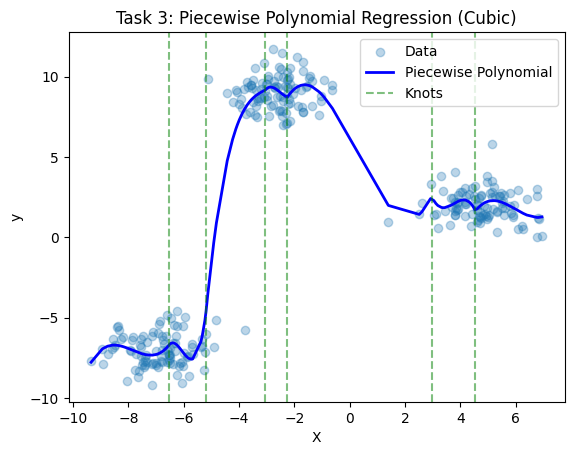

In [5]:
def piecewise_polynomial_features(X, knots, degree=3):
    """
    Create piecewise polynomial features using truncated power basis
    y = β₀ + β₁x + β₂x² + β₃x³ + 
        β₄(x-k₁)₊ + β₅(x-k₁)₊² + β₆(x-k₁)₊³ +
        β₇(x-k₂)₊ + β₈(x-k₂)₊² + β₉(x-k₂)₊³ + ...
    """
    X_flat = X.flatten()
    features = []
    
    # add polynomial terms
    for d in range(degree + 1):
        features.append(X_flat**d)
    
    # add truncated power basis for each knot
    for knot in knots:
        for d in range(1, degree + 1):
            features.append(np.maximum(0, X_flat - knot)**d)
    
    return np.column_stack(features)

# define hyperparameters for knot selection
max_knots = int(len(X) / 50)  # one knot per 50 data points
lower_perc = 20
upper_perc = 80

# test different numbers of knots using F-test
start_time = time.time()

for n_knots in range(1, max_knots+1):
    knots = np.percentile(X, np.linspace(lower_perc, upper_perc, n_knots))
    X_pw = piecewise_polynomial_features(X, knots)
    
    # fit the model, generate predictions
    model = LinearRegression()
    model.fit(X_pw, y)
    y_pred = model.predict(X_pw)
    
    # calculate RSS and F-statistic terms
    rss = np.sum((y - y_pred)**2)
    n = len(y)  # number of observations
    p = X_pw.shape[1]  # number of parameters
    
    # compare with simple polynomial
    if n_knots == 1:
        poly = PolynomialFeatures(degree=3)
        X_simple = poly.fit_transform(X)
        simple = LinearRegression()
        simple.fit(X_simple, y)
        
        rss_simple = np.sum((y - simple.predict(X_simple))**2)
        p_simple = X_simple.shape[1]
        f_stat_numer = (rss_simple - rss) / (p - p_simple)
        f_stat_denom = rss / (n - p)

    # compare with previous model
    else:
        f_stat_numer = (rss_prev - rss) / (p - p_prev)
        f_stat_denom = rss / (n - p)
        f_stat = f_stat_numer / f_stat_denom
    
    # conduct F-test
    if f_stat > stats.f.ppf(0.95, 3, n - p):
        best_knots_poly = knots
        best_f_poly = f_stat
    
    rss_prev = rss
    p_prev = p

# fit final model with best knots
X_pw_poly = piecewise_polynomial_features(X, best_knots_poly)
pw_poly_model = LinearRegression()
pw_poly_model.fit(X_pw_poly, y)
y_pred_pw_poly = pw_poly_model.predict(X_pw_poly)

# evaluate final model
rmse_pw_poly = np.sqrt(mean_squared_error(y, y_pred_pw_poly))
r2_pw_poly = r2_score(y, y_pred_pw_poly)
time_pw_poly = time.time() - start_time

# report metrics
print(f"Best F-statistic: {best_f_poly}")
print(f"Number of knots: {len(best_knots_poly)}")
print(f"RMSE: {rmse_pw_poly:.4f}")
print(f"R²: {r2_pw_poly:.4f}")

# plot model
plt.scatter(X, y, alpha=0.3)
sort_idx = np.argsort(X.flatten())  # get indices that sort X so X[sort_idx] is ascending
plt.plot(X[sort_idx], y_pred_pw_poly[sort_idx], 'b-', linewidth=2)
for knot in best_knots_poly:
    plt.axvline(x=knot, color='g', linestyle='--', alpha=0.5)
plt.title('Task 3: Piecewise Polynomial Regression (Cubic)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Data', 'Piecewise Polynomial', 'Knots'])
plt.show()

# Task 5
Try to model the multimodal Gaussian distribution built with single polynomial regression.


Best F-statistic: 11.3767438600773
Best degree: 9
RMSE: 1.8228
R²: 0.9244


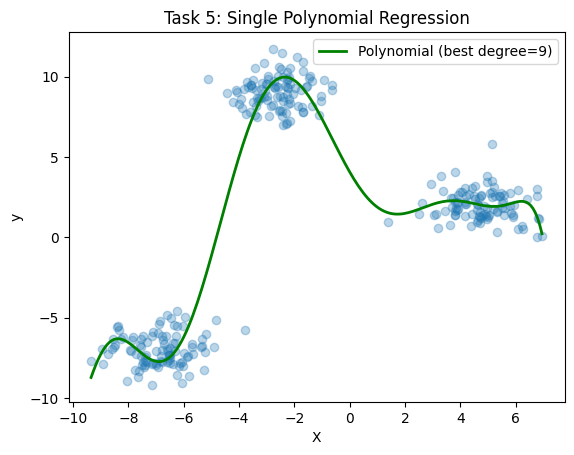

In [6]:
start_time = time.time()
best_degree = 1

# test different degrees using F-test
for degree in range(2, 10):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    # fit the model, generate predictions
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    # calculate RSS and F-statistic terms
    rss = np.sum((y - y_pred)**2)
    n = len(y)
    p = X_poly.shape[1]
    
    # compare with previous degree
    poly_prev = PolynomialFeatures(degree=degree-1)
    X_poly_prev = poly_prev.fit_transform(X)
    model_prev = LinearRegression()
    model_prev.fit(X_poly_prev, y)
    rss_prev = np.sum((y - model_prev.predict(X_poly_prev))**2)
    p_prev = X_poly_prev.shape[1]

    f_stat_numer = (rss_prev - rss) / (p - p_prev)
    f_stat_denom = rss / (n - p)
    f_stat = f_stat_numer / f_stat_denom
        
    # conduct F-test
    if f_stat > stats.f.ppf(0.95, p - p_prev, n - p):
        best_degree = degree
        best_f_sing_poly = f_stat

# fit final polynomial with best degree
poly = PolynomialFeatures(degree=best_degree)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

# evaluate final model
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
r2_poly = r2_score(y, y_pred_poly)
time_poly = time.time() - start_time

# report metrics
print(f"Best F-statistic: {best_f_sing_poly}")
print(f"Best degree: {best_degree}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R²: {r2_poly:.4f}")

# plot model
plt.scatter(X, y, alpha=0.3)
X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = poly_model.predict(poly.transform(X_plot))
plt.plot(X_plot, y_plot, 'green', linewidth=2, label=f'Polynomial (best degree={best_degree})')
plt.title('Task 5: Single Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Task 4
In addition to F-statistics that you use to decide about the number of knots, report RSME and R^2 for all models.

In [7]:
eval_metrics = {'Piecewise Linear': {'RMSE': rmse_pw_linear, 'R²': r2_pw_linear},
            'Piecewise Polynomial': {'RMSE': rmse_pw_poly, 'R²': r2_pw_poly},
            'Single Polynomial': {'RMSE': rmse_poly, 'R²': r2_poly}
}

pd.DataFrame(eval_metrics)

,Piecewise Linear,Piecewise Polynomial,Single Polynomial
RMSE,1.825930,1.590620,1.822793
R²,0.924171,0.942456,0.924431


> Interpretation:
> 
> Piecewise Linear and Single Polynomial have similar results while Piecewise Polynomial performs slightly better than both

# Task 6
Measure and report the execution time of tasks (2), task (3), and task (5). Then report the differences in execution time (no plot required, but
you need to report them in a table). Hint: use excel for table drawing and add it in the word file.


In [8]:
runtimes = {'Piecewise Linear': time_pw_linear, 
            'Piecewise Polynomial': time_pw_poly, 
            'Single Polynomial': time_poly
}

runtime_df = pd.DataFrame(runtimes, index=['Runtime (seconds)'])

# get differences
row_2 = [time_pw_linear-time_pw_linear, time_pw_poly-time_pw_linear, time_poly-time_pw_linear]
row_3 = [time_pw_linear-time_pw_poly, time_pw_poly-time_pw_poly, time_poly-time_pw_poly]
row_4 = [time_pw_linear-time_poly, time_pw_poly-time_poly, time_poly-time_poly]
runtime_df.loc['Minus PW Linear'] = row_2
runtime_df.loc['Minus PW Poly'] = row_3
runtime_df.loc['Minus Single Poly'] = row_4

runtime_df

,Piecewise Linear,Piecewise Polynomial,Single Polynomial
Runtime (seconds),0.008023,0.008485,0.013813
Minus PW Linear,0.000000,0.000462,0.005790
Minus PW Poly,-0.000462,0.000000,0.005328
Minus Single Poly,-0.005790,-0.005328,0.000000


> Interpretation:
> 
> Piecewise Linear and Piecewise Polynomial have similar runtimes while Single Polynomial performs slower than both

# Task 7
Use the Multimodal Gaussian distribution of Tasks 5, apply Ridge, LASSO and compare their accuracy and number of parameters, parameters coefficient with Polynomial regression. Here you should also report and discuss the differences (if there are any differences)


/Users/michaelkwok/opt/anaconda3/envs/spark-env/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.61939e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/michaelkwok/opt/anaconda3/envs/spark-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.953e+02, tolerance: 1.319e+00
  model = cd_fast.enet_coordinate_descent(


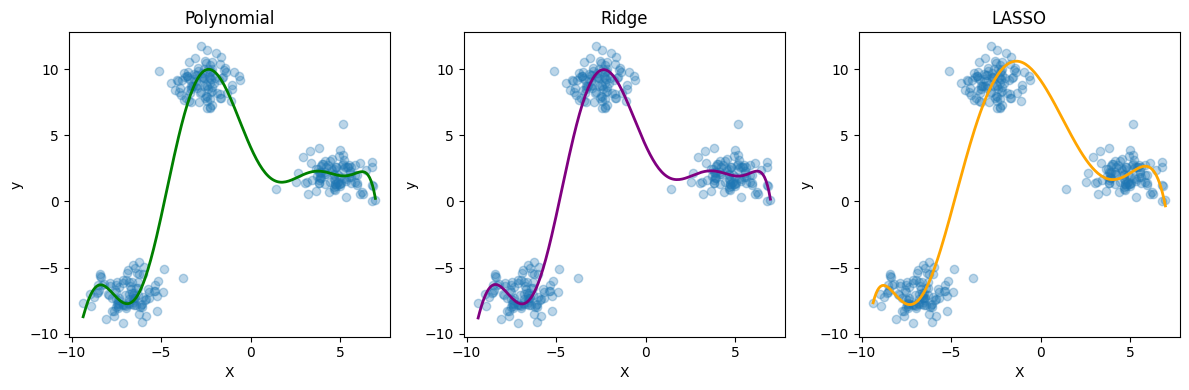

In [9]:
# use same polynomial features from Task 5

NONZERO_PARAM_THRESHOLD = 1e-10

# ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_poly, y)
y_pred_ridge = ridge.predict(X_poly)
rmse_ridge = np.sqrt(mean_squared_error(y, y_pred_ridge))
r2_ridge = r2_score(y, y_pred_ridge)

# LASSO
lasso = Lasso(alpha=0.1)
lasso.fit(X_poly, y)
y_pred_lasso = lasso.predict(X_poly)
rmse_lasso = np.sqrt(mean_squared_error(y, y_pred_lasso))
r2_lasso = r2_score(y, y_pred_lasso)

# count non-zero parameters
n_params_poly = np.sum(np.abs(poly_model.coef_) > NONZERO_PARAM_THRESHOLD)
n_params_ridge = np.sum(np.abs(ridge.coef_) > NONZERO_PARAM_THRESHOLD)
n_params_lasso = np.sum(np.abs(lasso.coef_) > NONZERO_PARAM_THRESHOLD)

# plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, alpha=0.3)
plt.plot(X_plot, poly_model.predict(poly.transform(X_plot)), 'green', linewidth=2)
plt.title('Polynomial')
plt.xlabel('X')
plt.ylabel('y')

plt.subplot(1, 3, 2)
plt.scatter(X, y, alpha=0.3)
plt.plot(X_plot, ridge.predict(poly.transform(X_plot)), 'purple', linewidth=2)
plt.title('Ridge')
plt.xlabel('X')
plt.ylabel('y')

plt.subplot(1, 3, 3)
plt.scatter(X, y, alpha=0.3)
plt.plot(X_plot, lasso.predict(poly.transform(X_plot)), 'orange', linewidth=2)
plt.title('LASSO')
plt.xlabel('X')
plt.ylabel('y')

plt.tight_layout()
plt.show()

In [10]:
eval_metrics = {'Piecewise Linear': {'RMSE': rmse_pw_linear, 'R²': r2_pw_linear},
            'Piecewise Polynomial': {'RMSE': rmse_pw_poly, 'R²': r2_pw_poly},
            'Single Polynomial': {'RMSE': rmse_poly, 'R²': r2_poly},
            'Ridge Polynomial': {'RMSE': rmse_ridge, 'R²': r2_ridge},
            'LASSO Polynomial': {'RMSE': rmse_lasso, 'R²': r2_lasso}
}

pd.DataFrame(eval_metrics)

,Piecewise Linear,Piecewise Polynomial,Single Polynomial,Ridge Polynomial,LASSO Polynomial
RMSE,1.825930,1.590620,1.822793,1.823039,2.029035
R²,0.924171,0.942456,0.924431,0.924411,0.906363


> Interpretation:
> 
> Piecewise Linear, Single Polynomial, and Ridge Polynomial have similar results while Piecewise Polynomial performs slightly better than both and LASSO Polynomial performs slightly worse than both

In [30]:
pd.DataFrame([{'Poly num params': n_params_poly, 'Ridge num params': n_params_ridge, 'LASSO num params': n_params_lasso}])

,Poly num params,Ridge num params,LASSO num params
0,9,9,9


> Interpretation:
> 
> Same parameters for all, so LASSO didn't zero-out any parameters.

In [ ]:
pd.DataFrame({'Poly coeff': poly_model.coef_, 'Ridge coeff': ridge.coef_, 'LASSO coeff': lasso.coef_})

,Poly,Ridge,LASSO
0,0.000000,0.000000,0.000000e+00
1,-3.003842,-2.915529,-1.962819e+00
2,0.615901,0.600729,-4.968835e-01
3,0.263549,0.252644,1.244458e-01
4,-0.063054,-0.062567,6.336062e-03
5,-0.008044,-0.007627,-1.151245e-03
6,0.001655,0.001653,3.294590e-05
7,0.000141,0.000135,-8.925172e-06
8,-0.000014,-0.000014,-1.394580e-06
9,-0.000001,-0.000001,3.110350e-08


> Interpretation:
> 
> Single Polynomial and Ridge Polynomial have similar coefficients different than LASSO Polynomial